In [1]:

import os

import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from scipy.signal import welch
#import regex as reg
from sklearn.pipeline import Pipeline
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import mne
import numpy as np
from scipy.stats import iqr
import warnings
import torch
from torch_geometric.data import Data
from utils.train_loop import train_riemannian_gnn
from models.RiemannianGAT import RiemannianGAT
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

mne.set_log_level('ERROR')   # silence MNE

warnings.filterwarnings("ignore")  # silence warnings

In [2]:
time_window = 0.5
fs = 500
cov_threshold = 0.3
ica = True

n_channels = 29

In [4]:
latest_channel_list = [
    # Left sensorimotor area channels
    'E29', 'E30', 'E35', 'E36', 'E41', 'E42',
    # Right sensorimotor area channels
    'E103', 'E104', 'E109', 'E110', 'E115', 'E116',
    # Mid-parietal & bilateral parietal
    'E62', 'E67', 'E72', 'E77'
 ]

new_latest = ['E24', 'E124', 'E36', 'E104', 'E47','E52', 'E60', 'E67', 'E72', 'E77', 'E85', 'E92', 'E98', 'E62','E70', 'E75', 'E83','E58','E96','E90','E65','E69','E74','E82','E89'
              ,'E1', 'E32','E14', 'E21']

bad_channels = ['E17', 'E38', 'E94', 'E113', 'E119', 'E121', 'E125', 'E128', 'E73', 'E81', 'E88', 'E43', 'E44', 'E120', 'E114','E127', 'E126',
                 'E68', 'E23', 'E3','E49','E48', "E8", "E25",
     "E56", "E63", "E99", "E107"]

bad_channels = ['E17', 'E38', 'E94', 'E113', 'E119', 'E121', 'E125', 'E128', 'E73', 'E81', 'E88', 'E43', 'E44', 'E120', 'E114','E127', 'E126',
                 'E68', 'E23', 'E3','E49','E48', "E8", "E25",
     "E56", "E63", "E99", "E107",]
                 
#bad_channels = ['E48', 'E119', 'E49', 'E113', 'E94', 'E68', 'E23', 'E3', 'E126', 'E127']



#label_dict = {'OBBA': 0, 'OBBY': 1, 'OBDO': 2, 'OBMO': 3, 'OBSI':4}
label_dict = {'IMMO': 0,'IMBY': 1,'IMSI':2 } # banana, baby, sitar
directions = ['IMMO', 'IMBY', 'IMSI']

#directions = ['OBBA', 'OBBY', 'OBDO', 'OBDO','OBSI']  # Left, Right, Up, Down

In [86]:
# # Your target list (cleaned of spaces and duplicates)
# wanted = new_latest

# # Generate every possible channel from E1 to E128
# all_128 = [f'E{i}' for i in range(1, 129)]

# # Create the discard list: everything that is NOT in your wanted list
# discard_list = [ch for ch in all_128 if ch not in wanted]

# print(f"Total channels to discard: {len(discard_list)}")

In [5]:
channel_tuple = (new_latest, bad_channels)

In [6]:

class preprocessing_pipeline:
    def __init__(self, filename, *channel_tuple, 
                 l_freq=10.0, h_freq=80.0, notch_freq=50.0, fs=500.0, time_window=time_window,
                 apply_ica=ica, remove_muscle=False,
                 eog_vertical_chs=('E14', 'E21'), eog_horizontal_chs=('E1', 'E32')):
        
        self.filename = filename
        self.l_freq = l_freq
        self.h_freq = h_freq
        self.notch_freq = notch_freq
        self.time_window = time_window
        self.fs = fs
        self.active_channels = channel_tuple[0]
        self.bad_channels = channel_tuple[1]
        self.apply_ica = apply_ica
        self.remove_muscle = remove_muscle
        self.eog_vertical_chs = list(eog_vertical_chs)
        self.eog_horizontal_chs = list(eog_horizontal_chs)
        self.ica = None  # Store for inspection later

        self.raw = self.file_process()
        self.annotations = self.raw.annotations

    def file_process(self):
        raw = mne.io.read_raw_egi(self.filename, preload=True)
        
        if 'VREF' in raw.ch_names:
            raw.drop_channels(['VREF'])


        
        raw.pick('eeg')
        raw.pick_channels(self.active_channels)

        
        # if self.bad_channels:
        #     raw.drop_channels([ch for ch in self.bad_channels if ch in raw.ch_names])

  

        # Filter BEFORE ICA (ICA needs broadband signal to detect artifacts)
        # Use 1Hz high-pass for ICA fitting even if analysis band is higher
        raw.notch_filter(freqs=self.notch_freq, picks='eeg', verbose=False, pad='edge')
        raw.filter(l_freq=1.0, h_freq=self.h_freq, picks='eeg', verbose=False, pad='edge')

        if self.apply_ica:
            raw = self._run_ica(raw)

        # Apply analysis band-pass AFTER ICA (if l_freq > 1.0)
        if self.l_freq > 1.0:
            raw.filter(l_freq=self.l_freq, h_freq=None, picks='eeg', verbose=False, pad='edge')

        # Average reference AFTER ICA
        raw.set_eeg_reference('average', projection=False)

        return raw

    def _run_ica(self, raw):
        """
        Adds EOG proxies, fits ICA, removes artifact components, 
        then strips proxy channels. Returns cleaned raw (EEG only).
        """
        # --- 1. Add EOG proxy channels temporarily ---
        eog_proxies_added = []

        vert_chs = [ch for ch in self.eog_vertical_chs if ch in raw.ch_names]
        if vert_chs:
            proxy = raw.copy().pick_channels(vert_chs).get_data().mean(axis=0)
            info = mne.create_info(['EOG_vertical'], raw.info['sfreq'], ch_types=['eog'])
            raw.add_channels([mne.io.RawArray(proxy[np.newaxis, :], info)], force_update_info=True)
            eog_proxies_added.append('EOG_vertical')

        horiz_chs = [ch for ch in self.eog_horizontal_chs if ch in raw.ch_names]
        if horiz_chs:
            proxy = raw.copy().pick_channels(horiz_chs).get_data().mean(axis=0)
            info = mne.create_info(['EOG_horizontal'], raw.info['sfreq'], ch_types=['eog'])
            raw.add_channels([mne.io.RawArray(proxy[np.newaxis, :], info)], force_update_info=True)
            eog_proxies_added.append('EOG_horizontal')

        # --- 2. Fit ICA on EEG channels only (not proxies) ---
        eeg_only = raw.copy().pick_types(eeg=True)
        rank = mne.compute_rank(eeg_only, tol=1e-6, tol_kind='relative')
        n_components = min(25, rank['eeg'])

        print(f"\n🔧 Fitting ICA with {n_components} components on {len(eeg_only.ch_names)} EEG channels...")
        ica = mne.preprocessing.ICA(
            n_components=n_components, 
            random_state=42,
            method='fastica', 
            max_iter=500
        )
        ica.fit(eeg_only)

        # --- 3. Detect bad components ---
        bad_components = []

        if 'EOG_vertical' in raw.ch_names:
            idx, _ = ica.find_bads_eog(raw, ch_name='EOG_vertical', threshold=2.5)
            print(f"  Vertical EOG (blinks): {idx}")
            bad_components.extend(idx)

        if 'EOG_horizontal' in raw.ch_names:
            idx, _ = ica.find_bads_eog(raw, ch_name='EOG_horizontal', threshold=2.5)
            print(f"  Horizontal EOG (saccades): {idx}")
            bad_components.extend(idx)

        if self.remove_muscle:
            try:
                idx, _ = ica.find_bads_muscle(raw, threshold=0.2)
                print(f"  Muscle artifacts: {idx}")
                bad_components.extend(idx)
            except Exception as e:
                print(f"  Muscle detection skipped: {e}")

        ica.exclude = sorted(set(bad_components))
        print(f"\n  Excluding {len(ica.exclude)}/{n_components} components: {ica.exclude}")
        self.ica = ica  # Save for later inspection

        # --- 4. Apply ICA to EEG-only copy, then re-attach annotations ---
        # Apply only to EEG channels (proxy channels are NOT passed to apply)
        raw_eeg_clean = ica.apply(eeg_only)  # operates on the eeg-only copy
        
        # Restore annotations (crop/copy loses them)
        raw_eeg_clean.set_annotations(raw.annotations)

        print(f"  ✅ ICA done. Final channel count: {len(raw_eeg_clean.ch_names)}")
        return raw_eeg_clean  # Pure EEG, proxies never re-added

    # def baseline_stats(self):
    #     """Extract baseline statistics."""

    #     try:
    #         tmin = [ann['onset'] for ann in self.annotations if ann['description'] == 'BLOS'][0]
    #         tmax = [ann['onset'] for ann in self.annotations if ann['description'] == 'BLOE'][0]

    #         baseline_raw = self.raw.copy().crop(tmin = tmin, tmax = tmax)
    #         baseline_data = baseline_raw.get_data(picks = 'eeg')

    #         # median = np.median(baseline_data, axis=1, keepdims=True)
    #         # scale = iqr(baseline_data, axis=1, keepdims=True)

    #         mean = np.mean(baseline_data, axis = 1 , keepdims = True)
    #         std  = np.std(baseline_data, axis = 1, keepdims = True)

    
    #     except Exception as e:
    #         tmin = [ann['onset'] for ann in self.annotations if ann['description'] == 'BSST'][0]
    #         tmax = [ann['onset'] for ann in self.annotations if ann['description'] == 'BSEN'][0]
    #         baseline_raw = self.raw.copy().crop(tmin = tmin, tmax = tmax)
    #         baseline_data = baseline_raw.get_data(picks = 'eeg')

    #         # median = np.median(baseline_data, axis=1, keepdims=True)
    #         # scale = iqr(baseline_data, axis=1, keepdims=True)

    #         mean = np.mean(baseline_data, axis = 1 , keepdims = True)
    #         std  = np.std(baseline_data, axis = 1, keepdims = True)

    #     return mean, std
    def baseline_stats(self):
        """Extract baseline statistics with multiple marker fallbacks."""
        baseline_data = None
        
        # Define pairs of (start, end) markers to look for
        marker_pairs = [('BLOS', 'BLOE'), ('BSST', 'BSEN')]
        
        for start_mark, end_mark in marker_pairs:
            try:
                tmin = [ann['onset'] for ann in self.annotations if ann['description'] == start_mark]
                tmax = [ann['onset'] for ann in self.annotations if ann['description'] == end_mark]
                baseline_raw = self.raw.copy().crop(tmin=tmin, tmax=tmax)
                baseline_data = baseline_raw.get_data(picks='eeg')
                print(f"✅ Using {start_mark}/{end_mark} for normalization.")
                break # Exit loop if found
            except (IndexError, Exception):
                continue

        # Final Fallback: If no markers found, use the whole recording
        if baseline_data is None:
            print("⚠️ No baseline markers found. Using full recording for normalization.")
            baseline_data = self.raw.get_data(picks='eeg')

        # Calculate stats channel-wise
        mean = np.mean(baseline_data, axis=1, keepdims=True)
        std  = np.std(baseline_data, axis=1, keepdims=True)

        # CRITICAL: Prevent division by zero for flat/dead channels
        std[std == 0] = 1.0 

        return mean, std
        

    def extracting_data(self, start_offset=0.0, end_offset=0.0, overlap_factor=0.75, normalize = True):
        base_mean, base_std = self.baseline_stats()
        #base_mean, base_std = 0, 1
        #classes = ['BA', 'BY', 'DO', 'MO', 'SI']
        classes = ['MO', 'BY', 'SI']
        # Changed from flat list to a dictionary grouped by class
        trial_groups = {cls: [] for cls in classes} 

        for cls in classes:
            starts = [ann['onset'] for ann in self.annotations if ann['description'] == f'IS{cls}']
            ends   = [ann['onset'] for ann in self.annotations if ann['description'] == f'IE{cls}']

            for start, end in zip(starts, ends):
                segment = self.raw.copy().crop(tmin=start+start_offset, tmax=end+end_offset)
                data = segment.get_data(picks='eeg').astype(np.float32)

                if normalize is not None:
                    data = (data - base_mean)/base_std

                window_samples = int(self.time_window * self.fs)
                step_samples = int(window_samples * (1-overlap_factor))
                
                total_samples = data.shape[1]
                this_trial_windows = []
                
                for start_pt in range(0, total_samples - window_samples + 1, step_samples):
                    chunk = data[:, start_pt:start_pt + window_samples]
                    this_trial_windows.append(chunk)

                if this_trial_windows:
                    # Store as a tuple: (Array of Windows, Label)
                    X_windows = np.stack(this_trial_windows, axis=0)
                    y_windows = np.full(X_windows.shape[0], label_dict[f'IM{cls}'])
                    trial_groups[cls].append((X_windows, y_windows))

        return trial_groups




In [7]:


# Point this to the parent "Data" directory
base_dir = "/Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/Data"
#base_dir = "/home/kavinfidel/projects/VM_EEG/Data"
#base_dir = "/Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/data_2"
subject_dirs = {}

# 1. Get all items in the Data folder
# 2. Filter for directories that start with 'S'
sub_folders = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f)) and f.startswith('S')]

for folder in sub_folders:
    folder_path = os.path.join(base_dir, folder)
    files = []
    
    # List all .mff files within each subject's folder
    for file_name in os.listdir(folder_path):
        if not file_name.startswith('.') and file_name.endswith('.mff'):
            files.append(file_name)
    
    # Using the actual folder name (e.g., 'S1', 'S113') as the key
    subject_dirs[folder] = files

# Verification
print(f"Found {len(subject_dirs)} subjects.")
print("Subjects identified:", list(subject_dirs.keys()))

Found 15 subjects.
Subjects identified: ['S116', 'S118', 'S5', 'S2', 'S119', 'S117', 'S3', 'S4', 'S2_', 'S1_', 'S1', 'S6', 'S115', 'S113', 'S114']


In [8]:
total_data = {}
test_data = {}

#base_dir = r'D:\0001_AK\KRISHNA\001_EEG_work_recent\extracted_files'


for subject, files in subject_dirs.items(): # subject is id, files are the all the files associated with a subject
    print(f"Processing {subject}")
    
    total_data[f"{subject}"] = {} #?
    test_data[f"{subject}"] = {}

    signals = [] #?
    labels = []#?
    signals_test = []
    labels_test = []

    k = 0
    for file_name in files:
        k +=1
        file_path = os.path.join(base_dir,subject, file_name) # grabbing file path, the mff file?
        
        if not file_name.endswith('.mff'):
            print(f"Skipping non-raw file: {file_name}")
            continue
        
        required_parts = ["signal1.bin", "info1.xml"]
        missing_parts = [p for p in required_parts if not os.path.exists(os.path.join(file_path, p))] # wha tis happenign here?
        if missing_parts:
            print(f"Skipping {file_name} due to parts being missing")
            continue
        
        print(f"File is intact: {file_name}\n Beginning extraction...")
        

        try:
            processor = preprocessing_pipeline(file_path, *channel_tuple)
            # trial_data is now a dict: {'BA': [(win, lab), (win, lab), (win, lab)], ...}
            trial_data = processor.extracting_data()

            if k == 2:
                print(f"Splitting Block {k} into Training and Test...")
                for cls, trials in trial_data.items():
                    # 1. Take the LAST trial (image event) for Testing
                    test_trial_x, test_trial_y = trials.pop() 
                    signals_test.append(test_trial_x)
                    labels_test.append(test_trial_y)

                    # 2. Put the REMAINING trials from this block into Training
                    for x, y in trials:
                        signals.append(x)
                        labels.append(y)
            else:
                # For Block 1 or 3, just put everything into Training
                for cls, trials in trial_data.items():
                    for x, y in trials:
                        signals.append(x)
                        labels.append(y)

        except Exception as e:
            print(f"Error processing {file_name}: {e}")
            continue

    
    total_data[f"{subject}"]['data'] = np.concatenate(signals, axis=0)
    total_data[f"{subject}"]['labels'] = np.concatenate(labels, axis=0)   
    
    test_data[f"{subject}"]['data'] = np.concatenate(signals_test, axis=0)
    test_data[f"{subject}"]['labels'] = np.concatenate(labels_test, axis=0)  



    

Processing S116
File is intact: VI_S6_S1_B3__20251116_110436.mff
 Beginning extraction...

🔧 Fitting ICA with 25 components on 29 EEG channels...
  Vertical EOG (blinks): [0, 1]
  Horizontal EOG (saccades): [0, 1]

  Excluding 2/25 components: [0, 1]
  ✅ ICA done. Final channel count: 29
⚠️ No baseline markers found. Using full recording for normalization.
File is intact: VI_SX_S2_B1_1__20260315_022327.mff
 Beginning extraction...

🔧 Fitting ICA with 25 components on 29 EEG channels...
  Vertical EOG (blinks): [0, 1]
  Horizontal EOG (saccades): [0, 6]

  Excluding 3/25 components: [0, 1, 6]
  ✅ ICA done. Final channel count: 29
⚠️ No baseline markers found. Using full recording for normalization.
Splitting Block 2 into Training and Test...
File is intact: VI_S6_S1_B1__20251116_104819.mff
 Beginning extraction...

🔧 Fitting ICA with 25 components on 29 EEG channels...
  Vertical EOG (blinks): [0, 1]
  Horizontal EOG (saccades): [0, 2]

  Excluding 3/25 components: [0, 1, 2]
  ✅ ICA don

In [9]:
for subject in total_data.keys():
    data = total_data[subject]['data']
    labels = total_data[subject]['labels']
    
    print(f"--- Verification for {subject} ---")
    print(f"Data Shape: {data.shape}") 
    # Expected: (Total_Windows, Channels, Samples_per_Window)
    # Example: (1500, 128, 50) 
    
    print(f"Labels Shape: {labels.shape}")
    print(f"Unique Labels: {np.unique(labels)}")
    
    # Check if classes are balanced (should be roughly equal)
    unique, counts = np.unique(labels, return_counts=True)
    print("Samples per class:", dict(zip(unique, counts)))
    print("-" * 30)
    

--- Verification for S116 ---
Data Shape: (1479, 29, 250)
Labels Shape: (1479,)
Unique Labels: [0 1 2]
Samples per class: {0: 493, 1: 493, 2: 493}
------------------------------
--- Verification for S118 ---
Data Shape: (696, 29, 250)
Labels Shape: (696,)
Unique Labels: [0 1 2]
Samples per class: {0: 232, 1: 232, 2: 232}
------------------------------
--- Verification for S5 ---
Data Shape: (696, 29, 250)
Labels Shape: (696,)
Unique Labels: [0 1 2]
Samples per class: {0: 232, 1: 232, 2: 232}
------------------------------
--- Verification for S2 ---
Data Shape: (696, 29, 250)
Labels Shape: (696,)
Unique Labels: [0 1 2]
Samples per class: {0: 232, 1: 232, 2: 232}
------------------------------
--- Verification for S119 ---
Data Shape: (696, 29, 250)
Labels Shape: (696,)
Unique Labels: [0 1 2]
Samples per class: {0: 232, 1: 232, 2: 232}
------------------------------
--- Verification for S117 ---
Data Shape: (696, 29, 250)
Labels Shape: (696,)
Unique Labels: [0 1 2]
Samples per class: {0

In [97]:
for subject in test_data.keys():
    data = test_data[subject]['data']
    labels = test_data[subject]['labels']
    
    print(f"--- Verification for {subject} ---")
    print(f"Data Shape: {data.shape}") 
    # Expected: (Total_Windows, Channels, Samples_per_Window)
    # Example: (1500, 128, 50) 
    
    print(f"Labels Shape: {labels.shape}")
    print(f"Unique Labels: {np.unique(labels)}")
    
    # Check if classes are balanced (should be roughly equal)
    unique, counts = np.unique(labels, return_counts=True)
    print("Samples per class:", dict(zip(unique, counts)))
    print("-" * 30)

--- Verification for S116 ---
Data Shape: (51, 29, 400)
Labels Shape: (51,)
Unique Labels: [0 1 2]
Samples per class: {0: 17, 1: 17, 2: 17}
------------------------------
--- Verification for S118 ---
Data Shape: (51, 29, 400)
Labels Shape: (51,)
Unique Labels: [0 1 2]
Samples per class: {0: 17, 1: 17, 2: 17}
------------------------------
--- Verification for S5 ---
Data Shape: (51, 29, 400)
Labels Shape: (51,)
Unique Labels: [0 1 2]
Samples per class: {0: 17, 1: 17, 2: 17}
------------------------------
--- Verification for S2 ---
Data Shape: (51, 29, 400)
Labels Shape: (51,)
Unique Labels: [0 1 2]
Samples per class: {0: 17, 1: 17, 2: 17}
------------------------------
--- Verification for S119 ---
Data Shape: (51, 29, 400)
Labels Shape: (51,)
Unique Labels: [0 1 2]
Samples per class: {0: 17, 1: 17, 2: 17}
------------------------------
--- Verification for S117 ---
Data Shape: (51, 29, 400)
Labels Shape: (51,)
Unique Labels: [0 1 2]
Samples per class: {0: 17, 1: 17, 2: 17}
---------

In [102]:
def riemannian_model_build(X_train,y_train,X_test, clf_type):
    cov_est = Covariances(estimator='oas')
    ts = TangentSpace(metric='riemann')
    #scaler = StandardScaler()
    
    # step 01
    cov_train = cov_est.fit_transform(X_train)
    cov_test = cov_est.transform(X_test)
    
    # Step 02
    X_train_ts = ts.fit_transform(cov_train)
    X_test_ts = ts.transform(cov_test)
    #scaler = StandardScaler()
    # St    ep 03
    #X_train_scaled = scaler.fit_transform(X_train_ts)
    #X_test_scaled = scaler.transform(X_test_ts)
    X_train_scaled = X_train_ts
    X_test_scaled = X_test_ts
    
    if clf_type == 'logreg':
        clf = LogisticRegression(
            penalty='l2',
            solver='lbfgs',
            class_weight='balanced',
            max_iter=1000
        )
    
    elif clf_type == 'svm':
        clf =   SVC(
            kernel='linear',
            class_weight='balanced',
            C=1.0
        )
    elif clf_type == 'xgboost':
        # Ensure y_train is 0-indexed for XGBoost
        clf = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3)
        
    elif clf_type == 'mlp':
        clf = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, early_stopping=True)
    else:
        raise ValueError('No classifier model supported')
    
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    
    return y_pred        

In [34]:
def calculate_de_from_array(chunk_data, sfreq=500):
    """
    chunk_data: (n_channels, n_samples) - e.g., (100, 315)
    Returns: (n_channels, n_bands)
    """
    # Fix shape if transposed
    if chunk_data.ndim == 2 and chunk_data.shape[0] != n_channels:
        chunk_data = chunk_data.T

    FREQ_BANDS = {
        'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 12),
        'beta': (12, 30), 'gamma': (30, 100)
    }

    n_samples = chunk_data.shape[-1]  # e.g., 315

    # freqs shape: (n_freq_bins,), psd shape: (n_channels, n_freq_bins)
    freqs, psd = welch(chunk_data, fs=sfreq, nperseg=n_samples)

    de_features = []
    for f_min, f_max in FREQ_BANDS.values():
        idx_band = np.logical_and(freqs >= f_min, freqs <= f_max)

        # psd is (n_channels, n_freq_bins) → index along freq axis (axis=1)
        band_psd = psd[:, idx_band] + 1e-10  # +1e-10 prevents log(0)

        # Differential entropy ≈ 0.5 * log(2πe * variance)
        # Summing log(psd) across freq bins is a valid approximation
        diff_entropy = np.sum(np.log(band_psd), axis=-1)  # (n_channels,)
        de_features.append(diff_entropy)

    return np.stack(de_features, axis=1) 

In [35]:
def convert_to_graph_list(X_data, y_labels, threshold=cov_threshold):
    """
    X_data: (n_trials, n_channels, n_samples)
    """
    graph_list = []

    cov_est = Covariances(estimator='oas')
    covariances = cov_est.fit_transform(X_data)  # (n_trials, n_channels, n_channels)

    for i in range(len(covariances)):
        x = X_data[i]  # ✅ Slice single trial: (n_channels, n_samples)
   
        x_mean = np.mean(x, axis=1)          # (n_channels,)
        x_std  = np.std(x, axis=1)
        x_skew = stats.skew(x, axis=1)
        x_kurt = stats.kurtosis(x, axis=1)

        time_stats = np.stack([x_mean, x_std, x_skew, x_kurt], axis=1)  # (n_channels, 4)

        de_stats = calculate_de_from_array(x)  # ✅ Pass single trial: (n_channels, 5)


  
        node_features = np.concatenate([time_stats, de_stats], axis=1)  # (n_channels, 9)

        scaler = StandardScaler()
        x_norm = scaler.fit_transform(node_features)  # ✅ call on instance
        x_tensor = torch.tensor(x_norm, dtype=torch.float32)

        adj = np.abs(covariances[i])
        rows, cols = np.where(adj > threshold)
        mask = rows != cols
        edge_index = torch.tensor(
            np.stack([rows[mask], cols[mask]], axis=0), dtype=torch.long
        )
        edge_attr = torch.tensor(
            adj[rows[mask], cols[mask]], dtype=torch.float32
        ).unsqueeze(1)

        y = torch.tensor([y_labels[i]], dtype=torch.long)

        graph_list.append(Data(
            x=x_tensor, edge_index=edge_index, edge_attr=edge_attr, y=y
        ))

    return graph_list

In [24]:
from models.graph_sage import GraphSAGE

In [25]:


def train_riemannian_gnn(train_dict, test_dict, test_sub, epochs=100, batch_size=8):
    # Setup Device
    device = torch.device(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    print(f"--- Testing Subject: {test_sub} on {device} ---")
    sub_list = ['S116', 'S118', 'S119', 'S117', 'S2_', 'S1_', 'S115', 'S113', 'S114']
    sub_list.remove(test_sub)
    X_all = []
    y_all = []

    for subject in sub_list:
        raw_data = train_dict[subject]['data']
        raw_labels = train_dict[subject]['labels']
        X_all.append(raw_data)
        y_all.append(raw_labels)

    # 1. Data Prep & Validation Split
    # Since you have small data, we split the train_dict further to get a validation set

    
    # Stratified split ensures class balance in tiny datasets
    # X_train, X_val, y_train, y_val = train_test_split(
    #     X_all, y_all, test_size=0.2, stratify=raw_labels, random_state=42
    # )
    X_train = np.concatenate(X_all, axis=0)
    y_train = np.concatenate(y_all, axis=0)
    
    X_val , y_val = np.array(test_dict[test_sub]['data']), np.array(test_dict[test_sub]['labels'])

    train_graphs = convert_to_graph_list(X_train, y_train)
    val_graphs = convert_to_graph_list(X_val, y_val)
    test_graphs = convert_to_graph_list(test_dict[test_sub]['data'], test_dict[test_sub]['labels'])

    train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

    # 2. Initialize Model
    #model = RiemannianGAT(in_channels=38, hidden_channels=64, out_channels=3).to(device)
    model = GraphSAGE(in_channels=9, hidden_channels=64, out_channels=3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # Added weight decay for small data
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    
    # 3. Training Loop
    for epoch in range(1, epochs + 1):
        model.train()
        total_train_loss = 0
        
        for batch in train_loader:
            batch = batch.to(device) # Move data to MPS
            # print(f"Node Features (x) Shape: {batch.x.shape}")        # Should be [Nodes, 5]
            # print(f"Edge Index Shape: {batch.edge_index.shape}")      # MUST BE [2, Edges]
            # print(f"Batch Vector Shape: {batch.batch.shape}")
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y.long().squeeze())
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        # 4. Validation Phase (The "Better" Part)
        model.eval()
        total_val_loss = 0
        correct = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                #out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                out = model(batch.x, batch.edge_index, batch.batch)
                
                total_val_loss += criterion(out, batch.y.long().squeeze()).item()
                pred = out.argmax(dim=1)
                correct += (pred == batch.y.long().squeeze()).sum().item()

        avg_val_loss = total_val_loss / len(val_loader)
        acc = correct / len(val_graphs)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Train Loss: {total_train_loss/len(train_loader):.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {acc:.2f}")
            
        # Simple Early Stopping Logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f'best_model_{subject}.pth') # Optional: Save best weights

    return model, test_loader



In [26]:



def evaluate_riemannian_gnn(model, test_loader, device, class_names=['DO', 'BY', 'SI']):
   # model = torch.load(best_model)
    model.eval()
    all_preds = []
    all_labels = []

    print("🧐 Evaluating on test set...")
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            # Forward pass
            out = model(batch.x, batch.edge_index, batch.batch)
            preds = out.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())

    # --- 1. Metrics ---
    print("\n✅ Evaluation Complete.")
    print(classification_report(all_labels, all_preds, target_names=class_names[:len(np.unique(all_labels))]))

    # --- 2. Confusion Matrix Plot ---
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names[:len(np.unique(all_labels))])
    disp.plot(cmap='Blues', ax=ax, values_format='.2f')
    plt.title("GNN Riemannian Confusion Matrix")
    plt.show()

    return all_labels, all_preds

In [27]:
model, test_loader = train_riemannian_gnn(total_data, test_data, subject, epochs=1000)

--- Testing Subject: S114 on cpu ---


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 100 and the array at index 1 has size 250

In [ ]:
device = torch.device('cpu')

# 3. Test the model
y_true, y_pred = evaluate_riemannian_gnn(model, test_loader, device)

## model performance with confusion matrix

In [103]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

In [104]:
def model_performance(train_dict, test_dict, clf_type, class_names=['MO', 'BY', 'SI']):
    total_acc_results = {}
    
    # We iterate over subjects in the training dictionary
    for subject in train_dict.keys():
        # Safety check: make sure this subject actually has a test block
        if subject not in test_dict or 'data' not in test_dict[subject]:
            print(f"Skipping {subject}: No test data found.")
            continue

        print(f"--- Evaluating {subject} ---")
        
        # 1. Prepare Training Data (all blocks except the 3rd)
        X_train = train_dict[subject]['data']
        y_train = train_dict[subject]['labels']
        
        # 2. Prepare Test Data (the 3rd block we kept separate)
        X_test = test_dict[subject]['data']
        y_test = test_dict[subject]['labels']
        
        print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

        # 3. Predict 
        # We don't need the loop for K-Fold anymore because we have a fixed test set
        y_pred = riemannian_model_build(X_train, y_train, X_test, clf_type)
        
        # 4. Calculate Accuracy
        acc = accuracy_score(y_test, y_pred)
        total_acc_results[subject] = acc
        print(f"Final Test Accuracy: {acc:.4f}")

        # 5. Plot Confusion Matrix for this specific test block
        cm = confusion_matrix(y_test, y_pred, normalize='true')
        
        fig, ax = plt.subplots(figsize=(8, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(cmap='Blues', ax=ax, values_format='.2g')
        plt.title(f"Hold-out Test: {subject} ({clf_type})")
        
        # Save and Show
        #save_path = f"/Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/confusion_matrices/holdout_{clf_type}_{subject}.png"
        #plt.savefig(save_path)
        plt.show()
    
    return total_acc_results

--- Evaluating S116 ---
Train samples: 867 | Test samples: 51
Final Test Accuracy: 0.6078


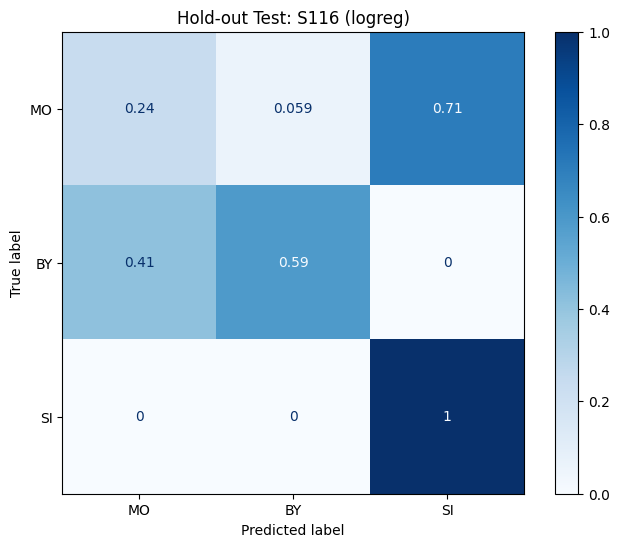

--- Evaluating S118 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.6078


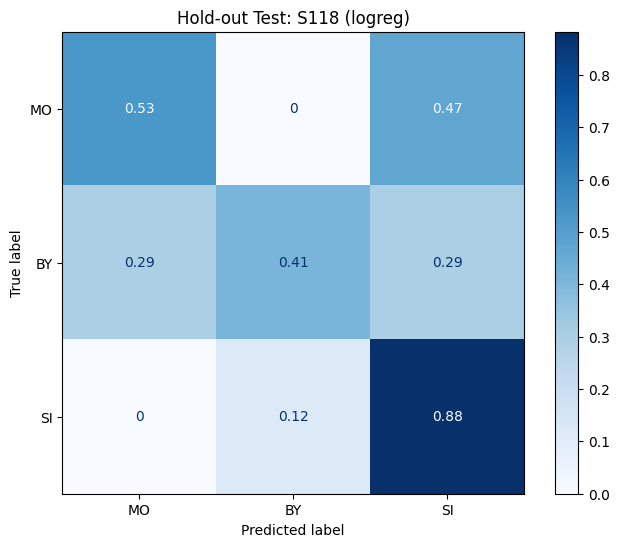

--- Evaluating S5 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.4314


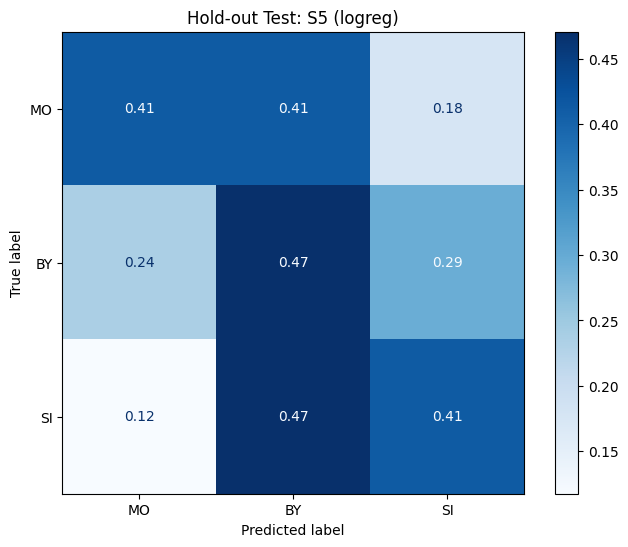

--- Evaluating S2 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.7059


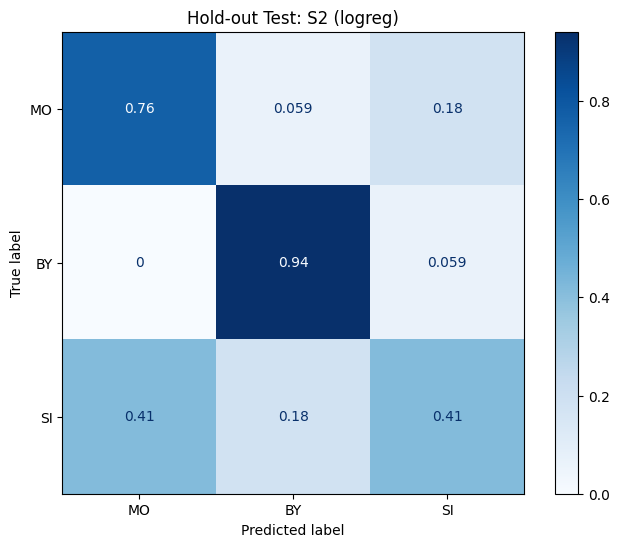

--- Evaluating S119 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.3922


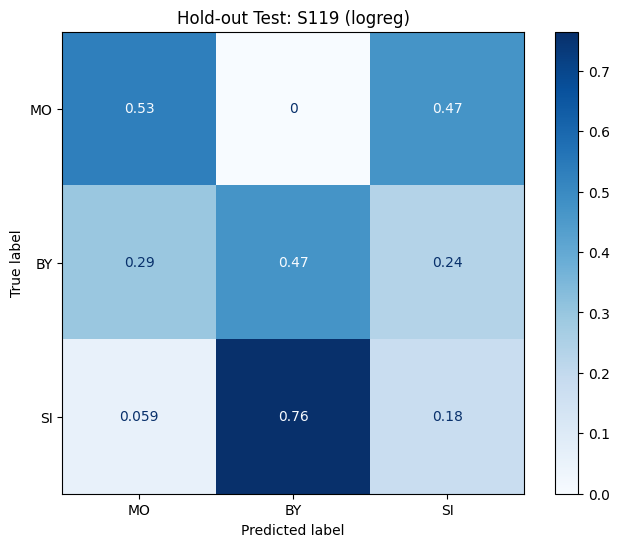

--- Evaluating S117 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.3922


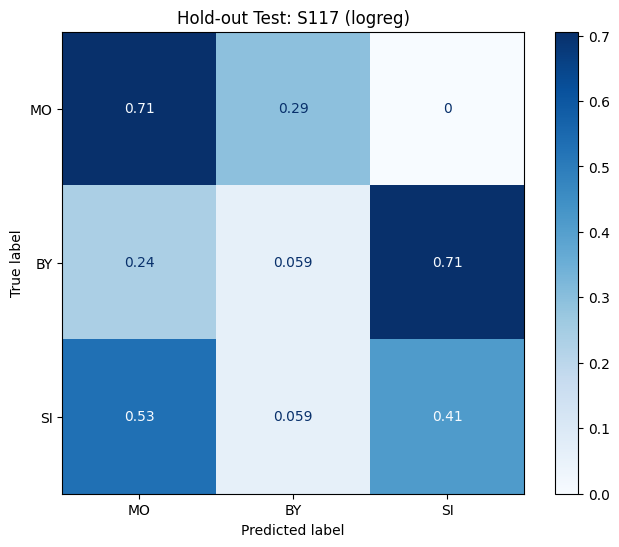

--- Evaluating S3 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.5882


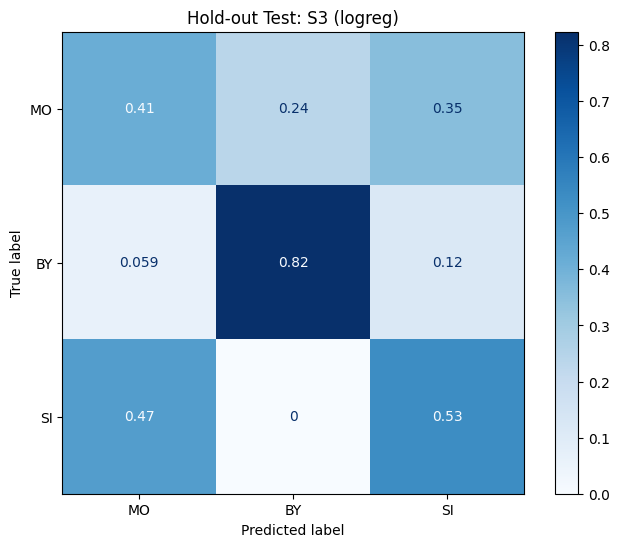

--- Evaluating S4 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.1569


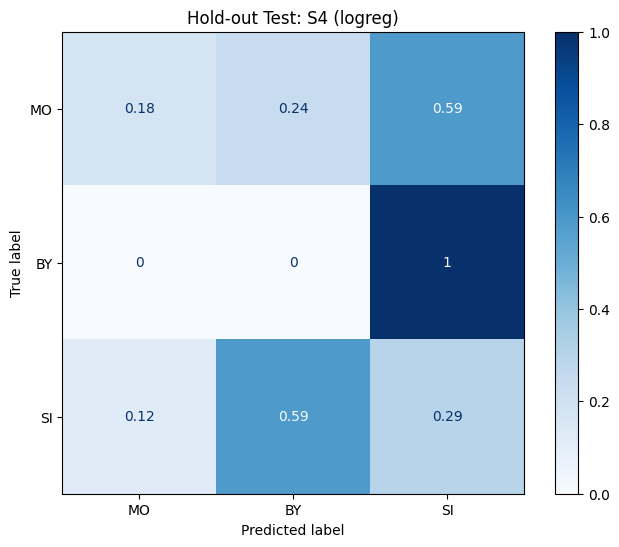

--- Evaluating S2_ ---
Train samples: 867 | Test samples: 51
Final Test Accuracy: 0.3922


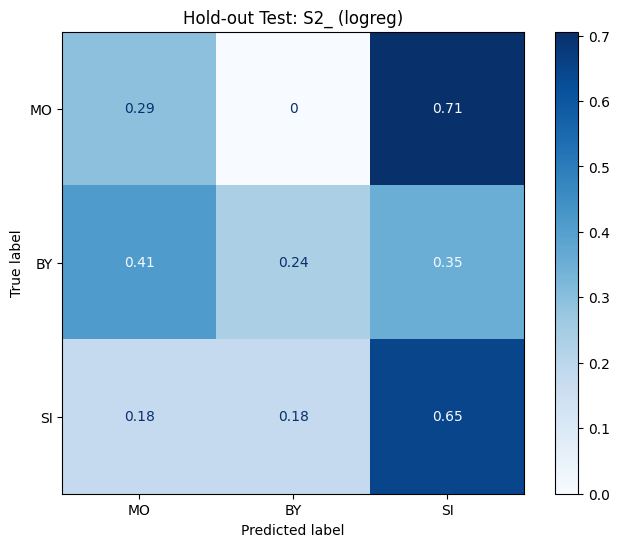

--- Evaluating S1_ ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.4314


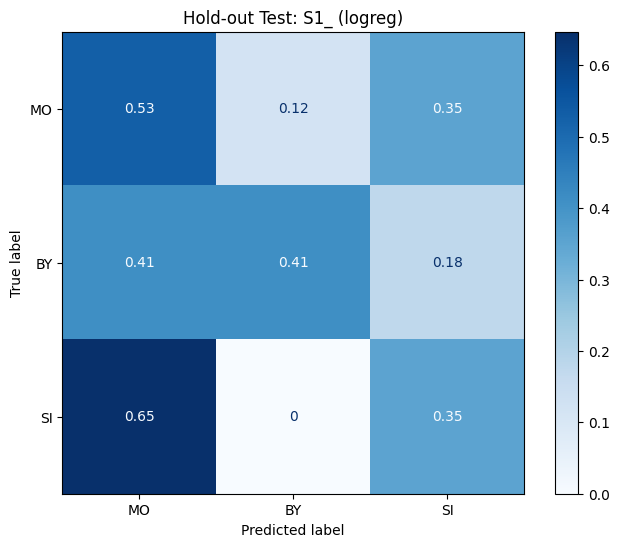

--- Evaluating S1 ---
Train samples: 561 | Test samples: 51
Final Test Accuracy: 0.2941


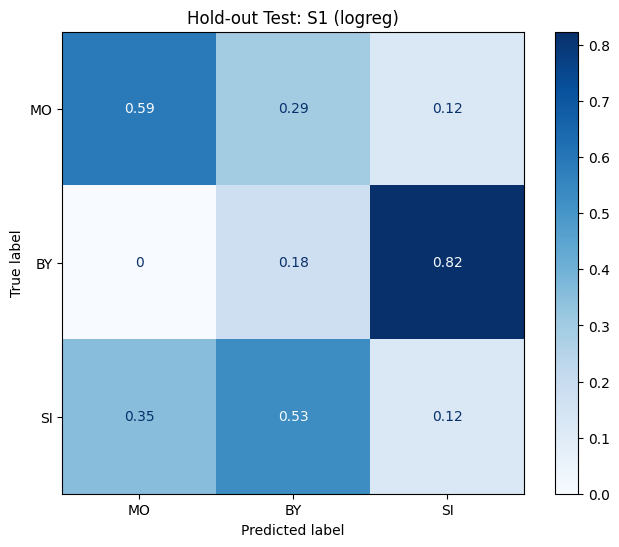

--- Evaluating S6 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.4118


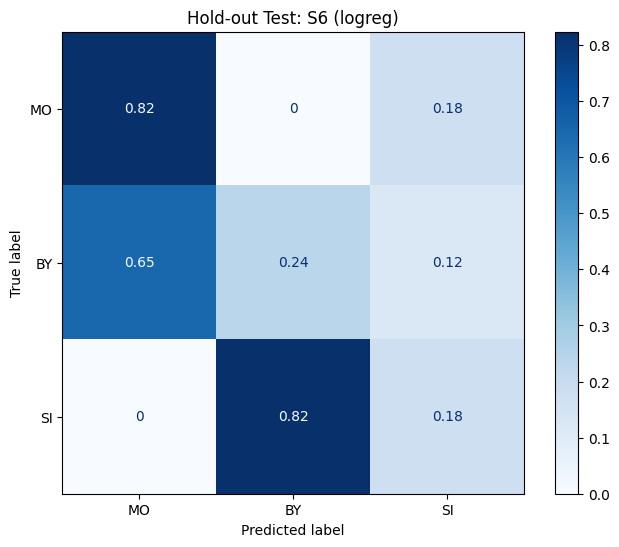

--- Evaluating S115 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.4314


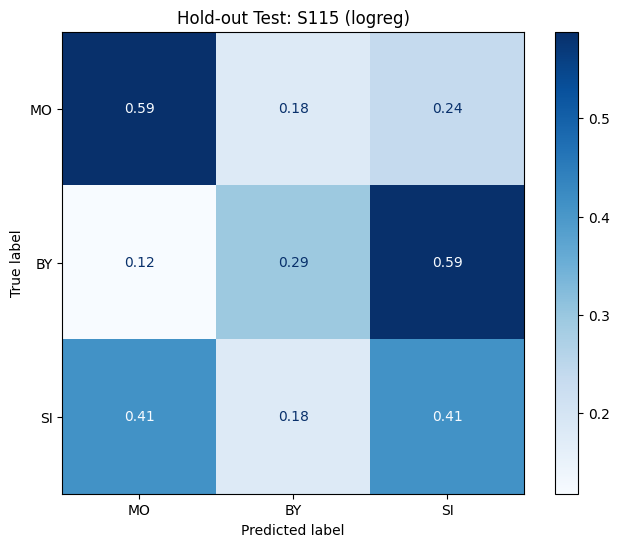

--- Evaluating S113 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.5294


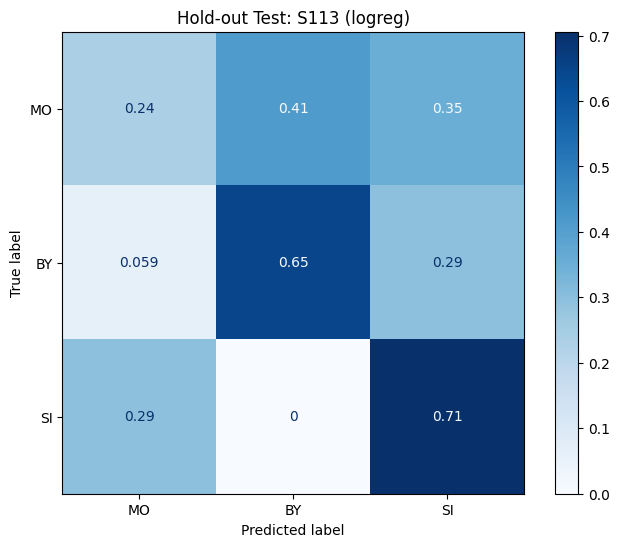

--- Evaluating S114 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.2745


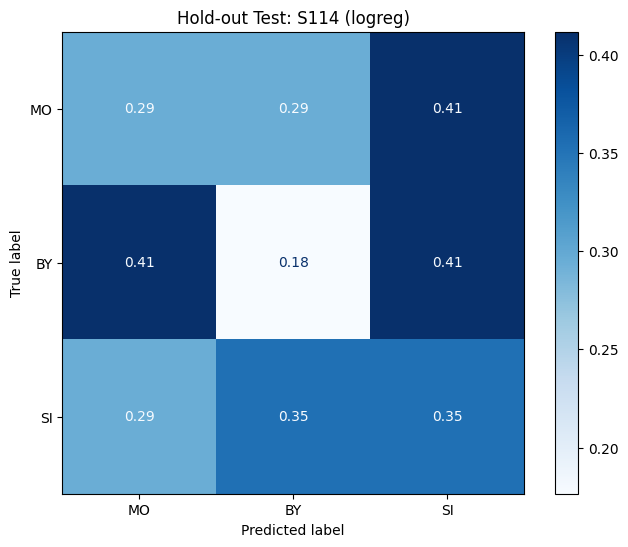

In [101]:

logreg_acc_dict = model_performance(total_data,test_data, clf_type='logreg')

In [76]:
import json

# Save the dictionary to a file
with open('logreg_acc_results_0.4_chunk.json', 'w') as f:
    json.dump(logreg_acc_dict, f, indent=4)

print("Results saved to logreg_acc_results.json")

# To load it back later:
# with open('logreg_acc_results.json', 'r') as f:
#     loaded_results = json.load(f)

Results saved to logreg_acc_results.json


--- Evaluating S116 ---
Train samples: 867 | Test samples: 51
Final Test Accuracy: 0.5686


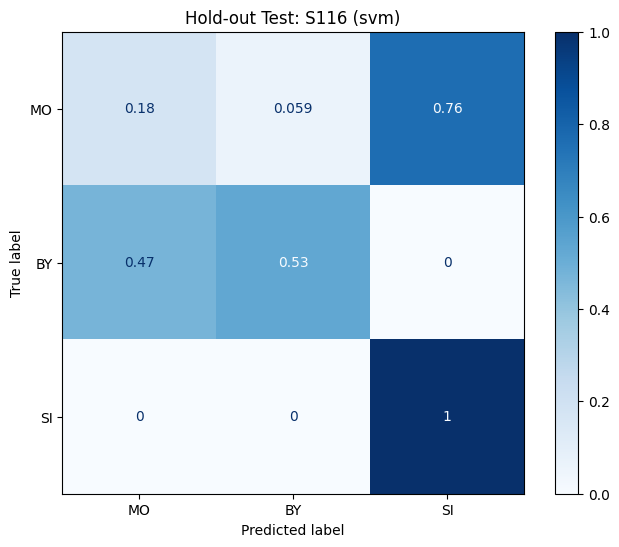

--- Evaluating S118 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.4902


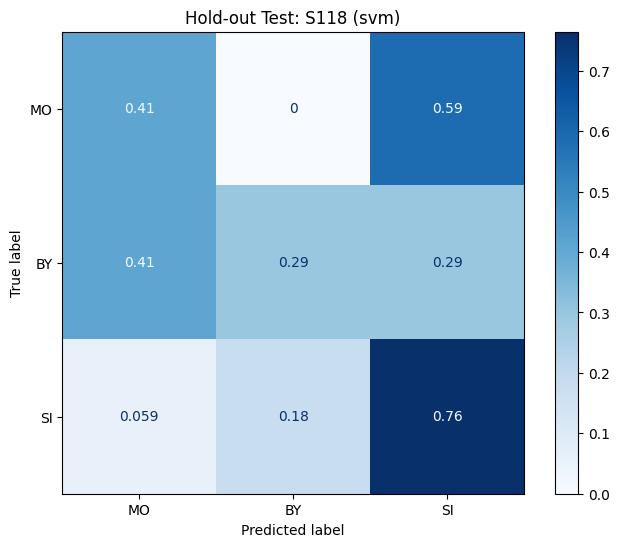

--- Evaluating S5 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.4314


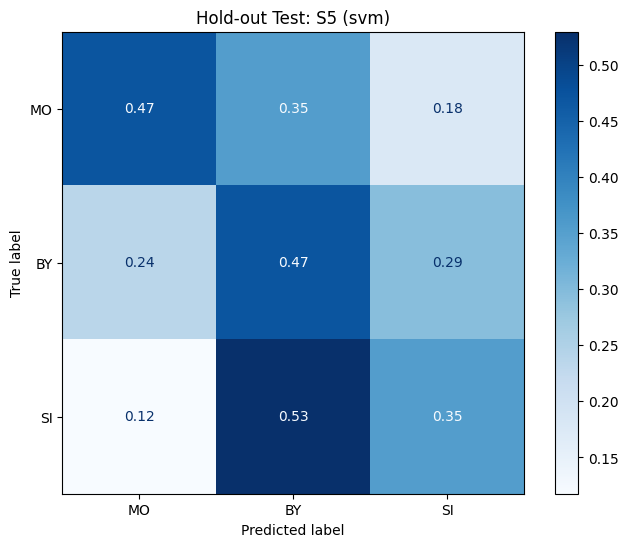

--- Evaluating S2 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.6275


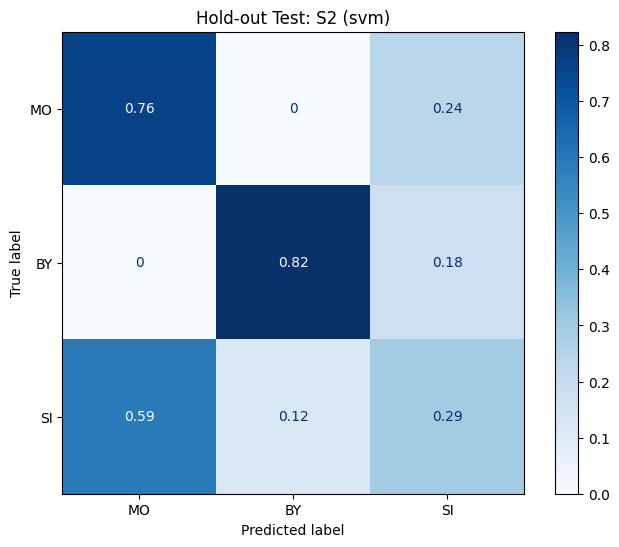

--- Evaluating S119 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.5098


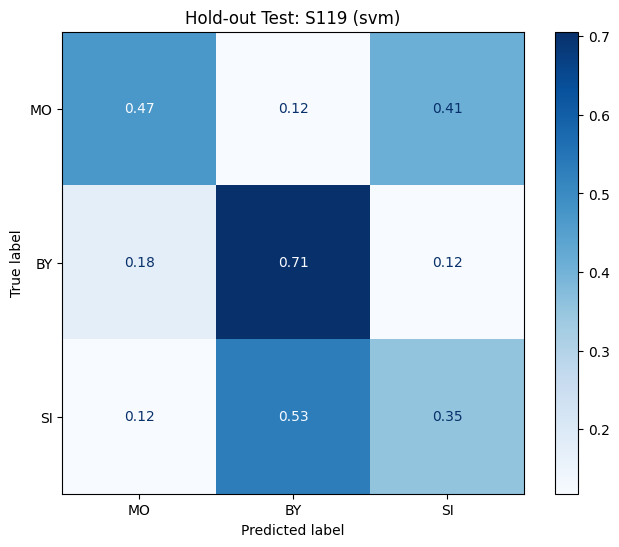

--- Evaluating S117 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.3725


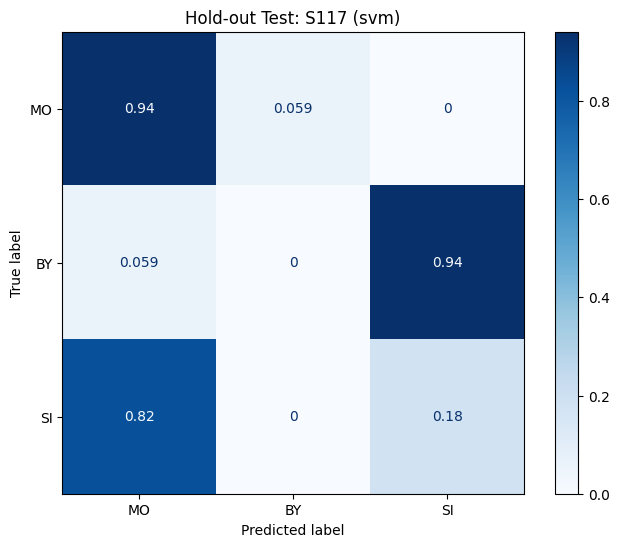

--- Evaluating S3 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.6078


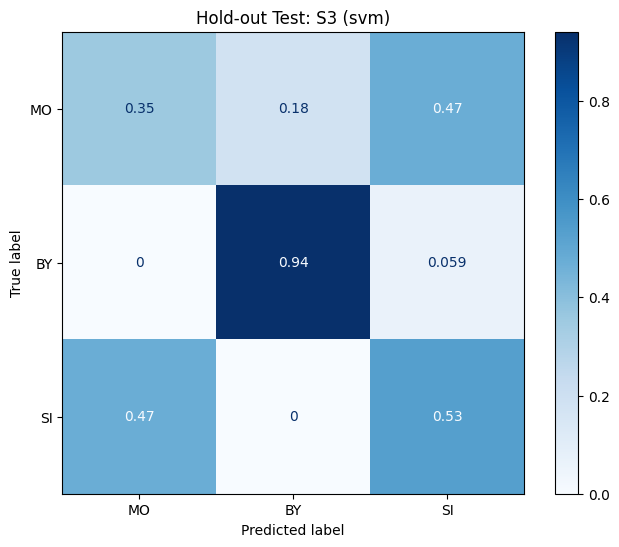

--- Evaluating S4 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.3137


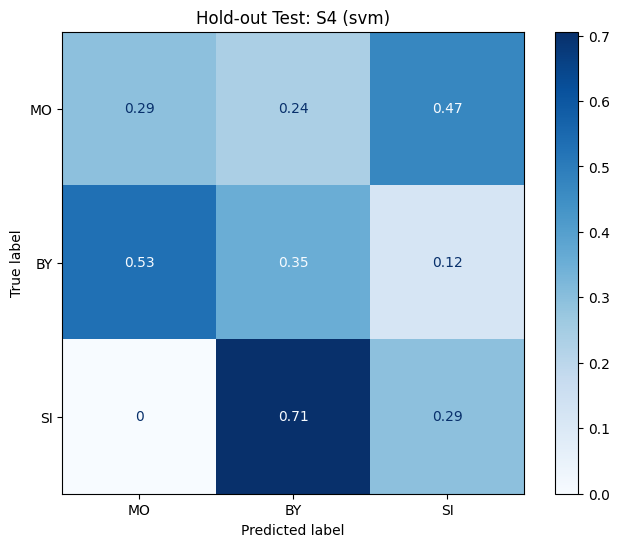

--- Evaluating S2_ ---
Train samples: 867 | Test samples: 51
Final Test Accuracy: 0.3333


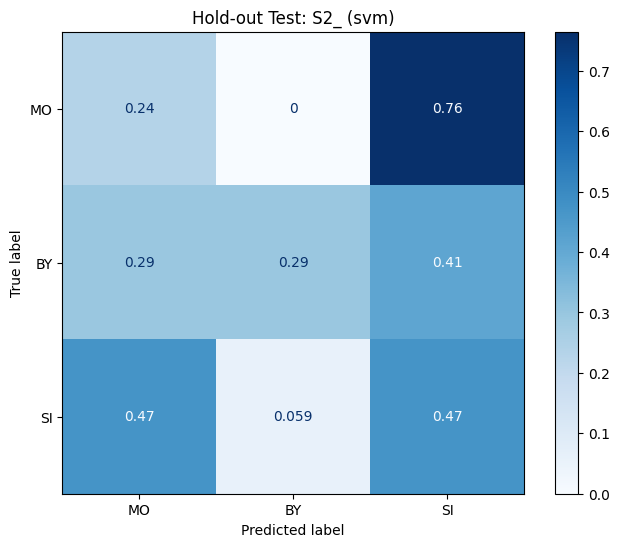

--- Evaluating S1_ ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.4118


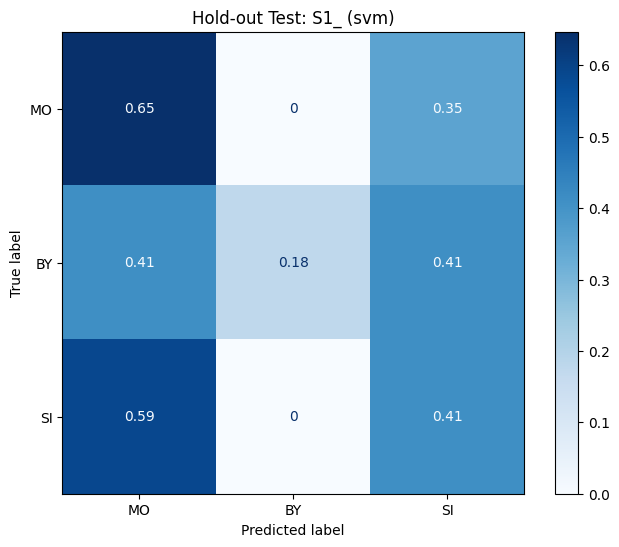

--- Evaluating S1 ---
Train samples: 561 | Test samples: 51
Final Test Accuracy: 0.3137


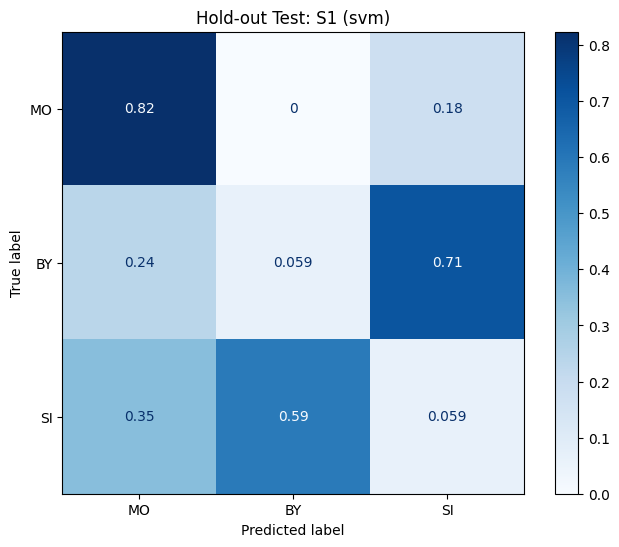

--- Evaluating S6 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.4706


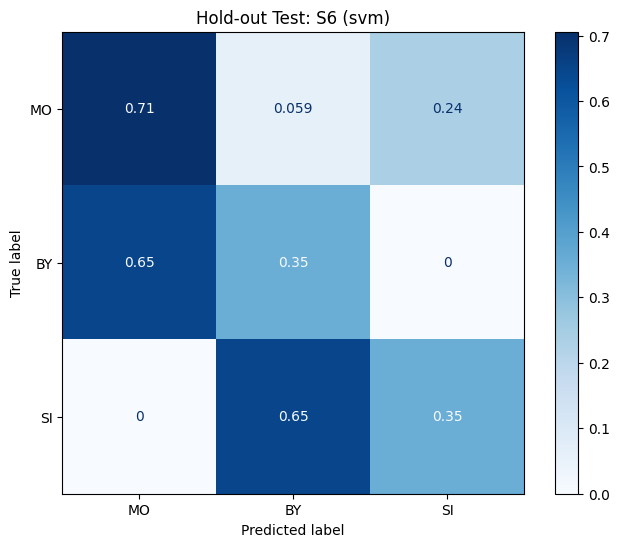

--- Evaluating S115 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.4902


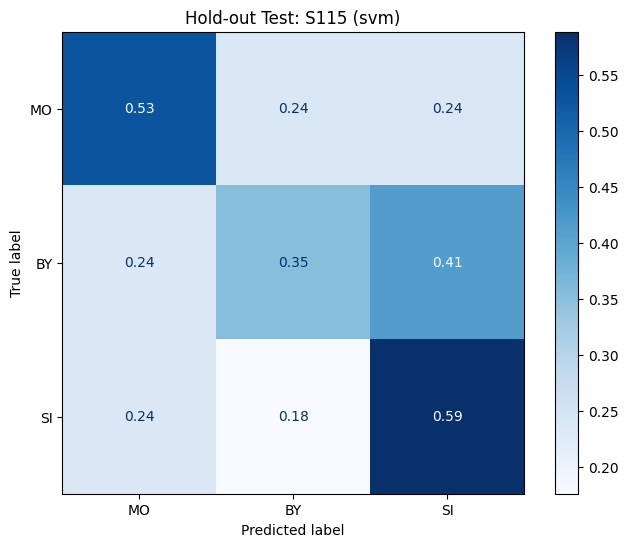

--- Evaluating S113 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.6078


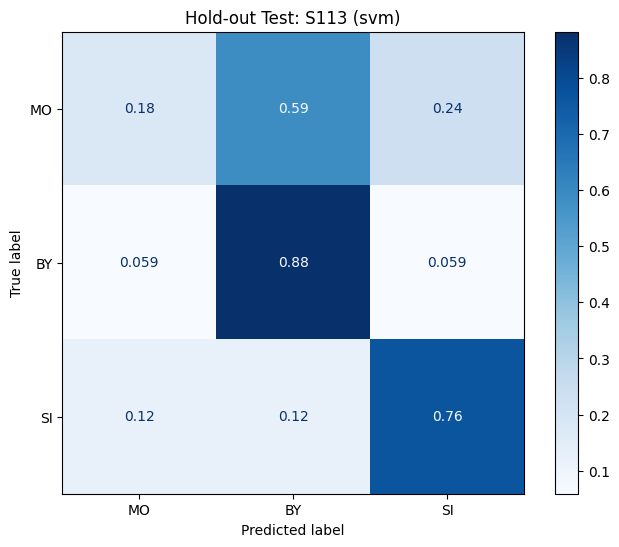

--- Evaluating S114 ---
Train samples: 408 | Test samples: 51
Final Test Accuracy: 0.4314


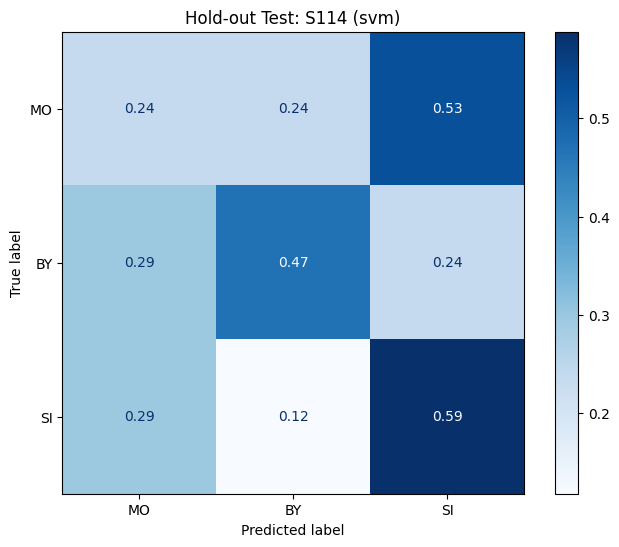

In [105]:
svm_acc_dict = model_performance(total_data, test_data,clf_type='svm')

In [ ]:
import json

In [ ]:

with open('svm_acc_results_0.5_chunk.json', 'w') as f:
    json.dump(svm_acc_dict, f, indent=4)

--- Evaluating S116 ---
Train samples: 306 | Test samples: 18
Final Test Accuracy: 0.2222


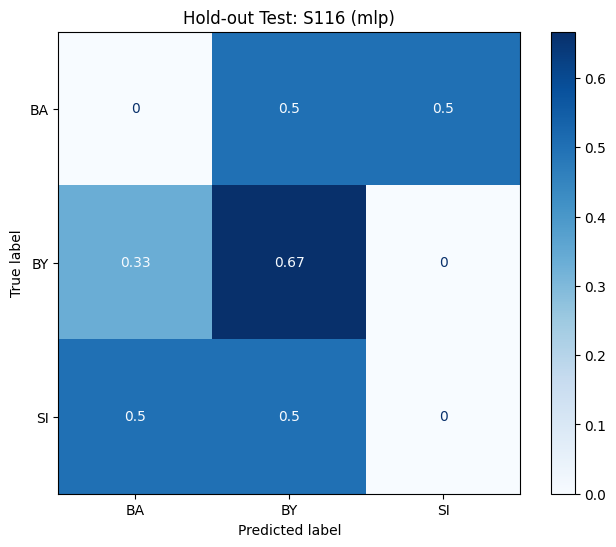

--- Evaluating S118 ---
Train samples: 144 | Test samples: 18
Final Test Accuracy: 0.1667


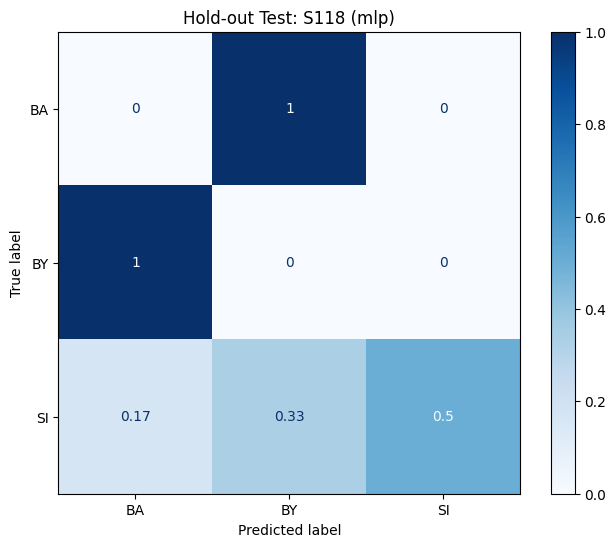

--- Evaluating S119 ---
Train samples: 144 | Test samples: 18
Final Test Accuracy: 0.3889


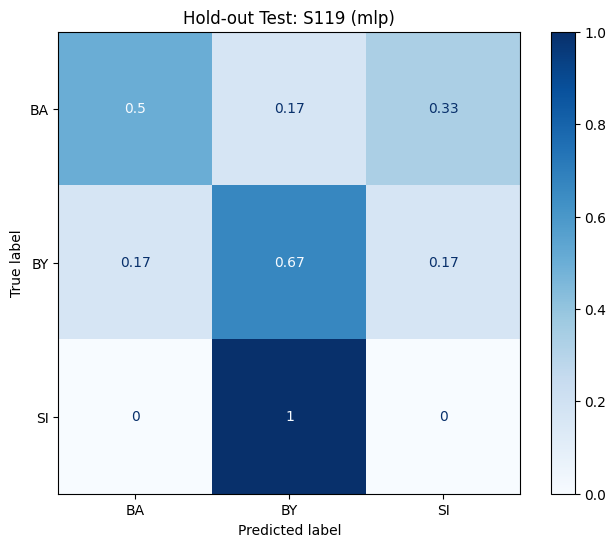

--- Evaluating S117 ---
Train samples: 144 | Test samples: 18
Final Test Accuracy: 0.2778


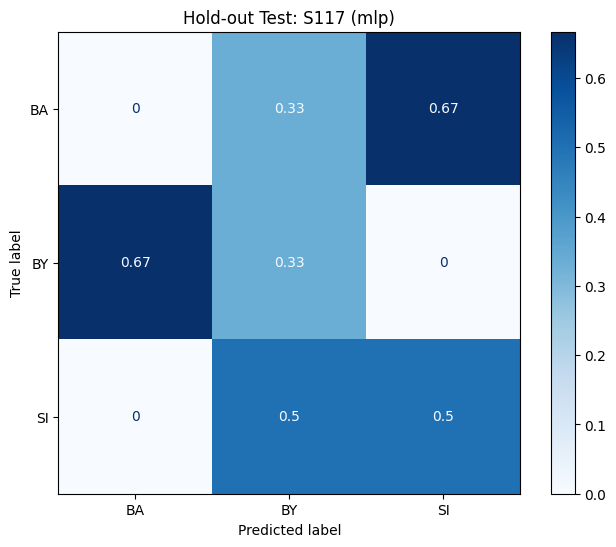

--- Evaluating S2_ ---
Train samples: 306 | Test samples: 18
Final Test Accuracy: 0.2778


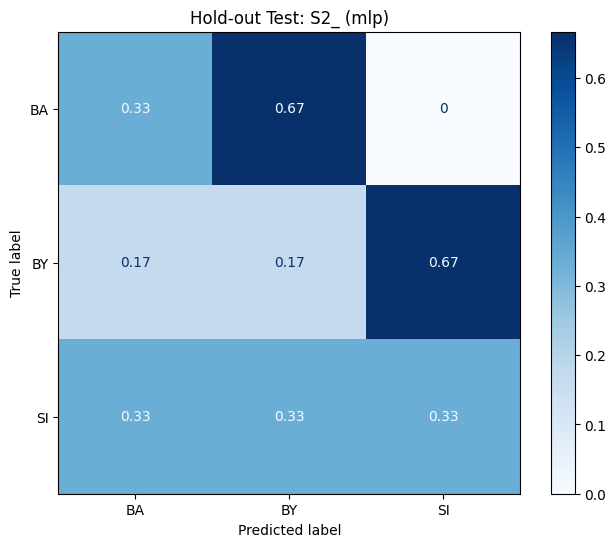

--- Evaluating S1_ ---
Train samples: 144 | Test samples: 18
Final Test Accuracy: 0.5000


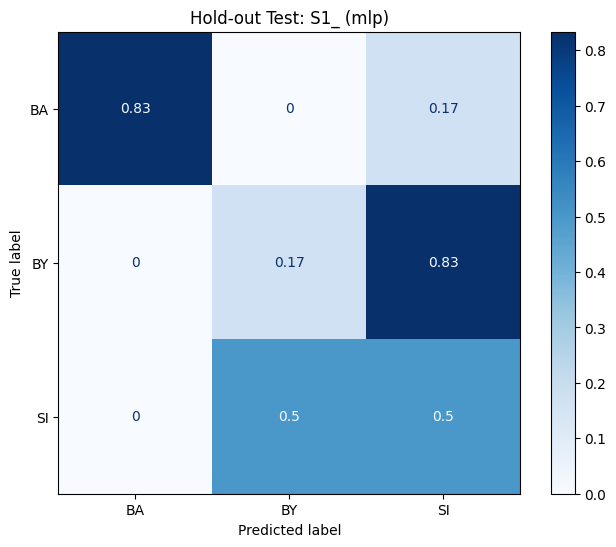

--- Evaluating S115 ---
Train samples: 144 | Test samples: 18
Final Test Accuracy: 0.2778


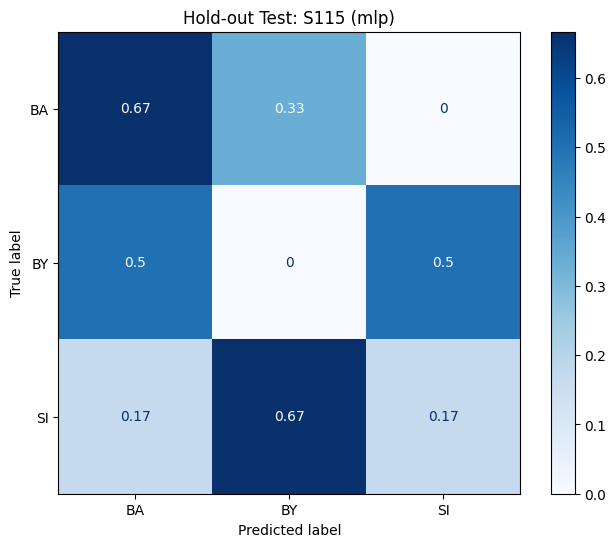

--- Evaluating S113 ---
Train samples: 144 | Test samples: 18
Final Test Accuracy: 0.6667


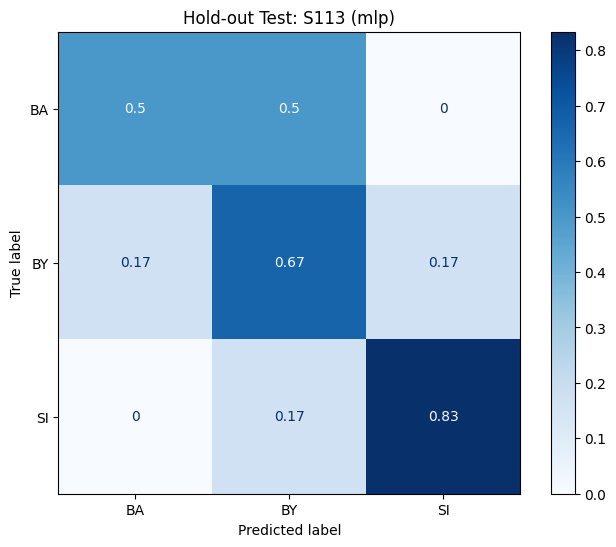

--- Evaluating S114 ---
Train samples: 144 | Test samples: 18
Final Test Accuracy: 0.3333


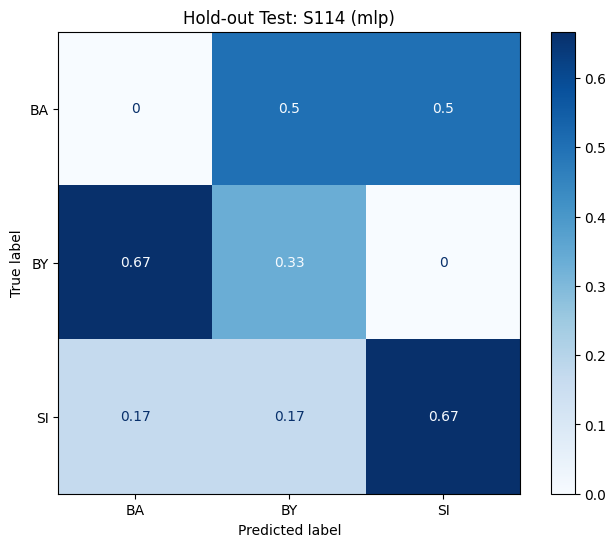

In [ ]:
mlp_acc_dict = model_performance(total_data, test_data,clf_type='mlp')

--- Evaluating S116 ---
Train samples: 306 | Test samples: 18
Final Test Accuracy: 0.3889


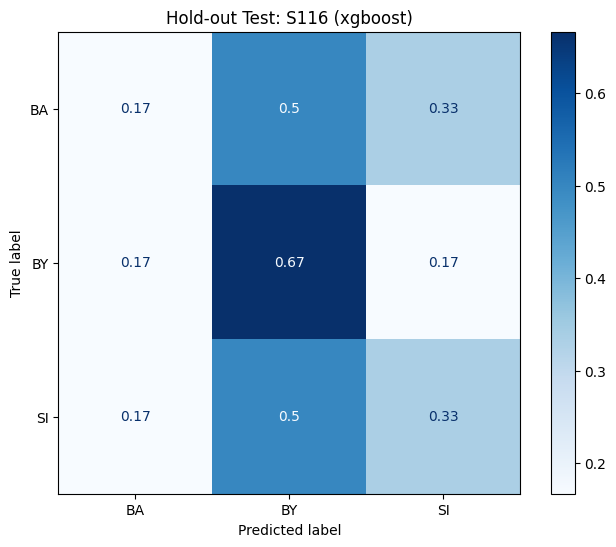

--- Evaluating S118 ---
Train samples: 144 | Test samples: 18
Final Test Accuracy: 0.3333


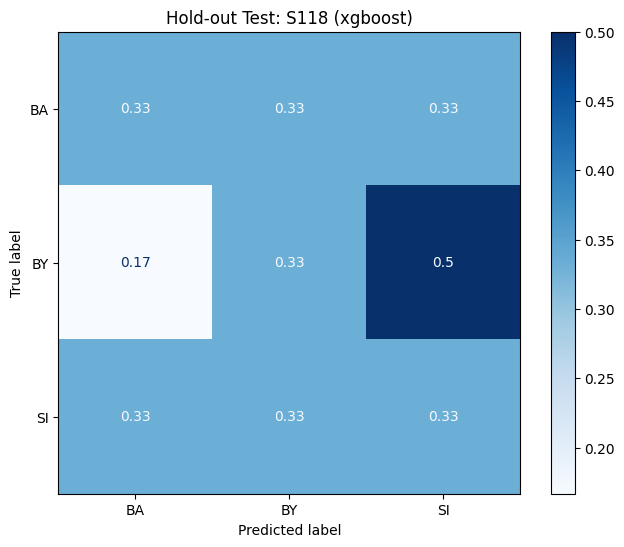

--- Evaluating S119 ---
Train samples: 144 | Test samples: 18
Final Test Accuracy: 0.5000


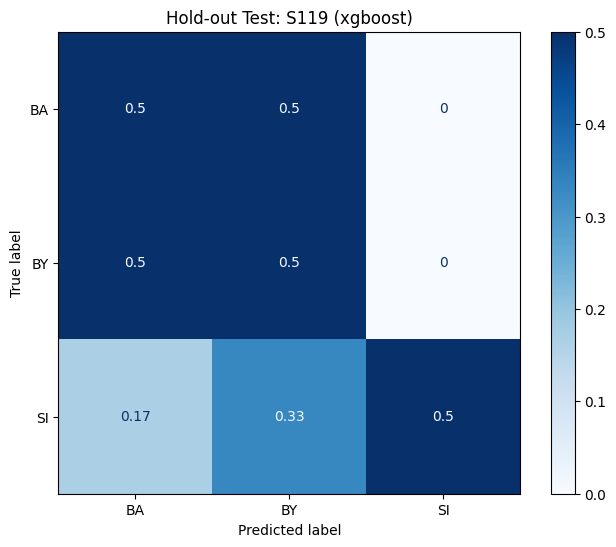

--- Evaluating S117 ---
Train samples: 144 | Test samples: 18
Final Test Accuracy: 0.2222


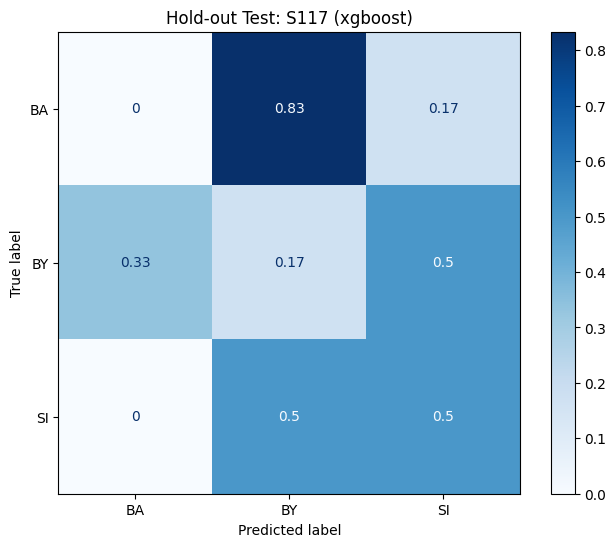

--- Evaluating S2_ ---
Train samples: 306 | Test samples: 18
Final Test Accuracy: 0.3333


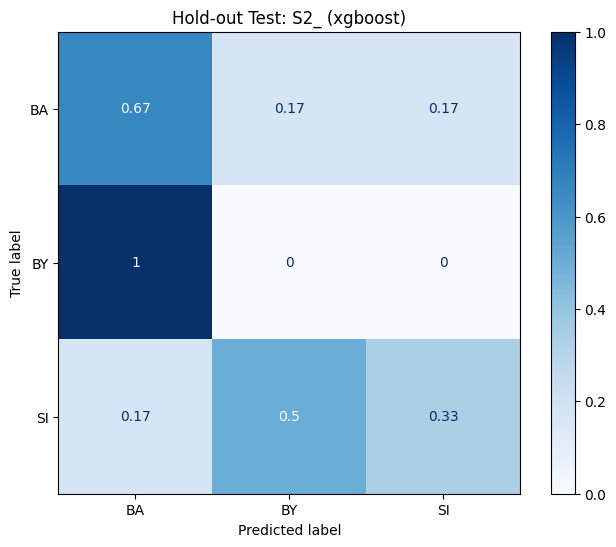

--- Evaluating S1_ ---
Train samples: 144 | Test samples: 18
Final Test Accuracy: 0.6667


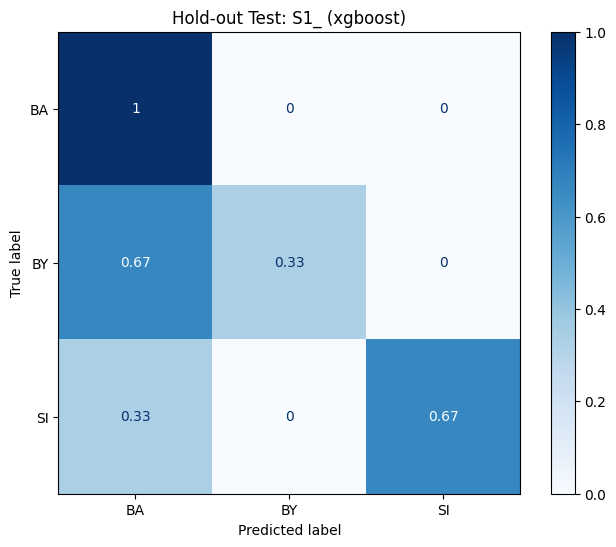

--- Evaluating S115 ---
Train samples: 144 | Test samples: 18
Final Test Accuracy: 0.3333


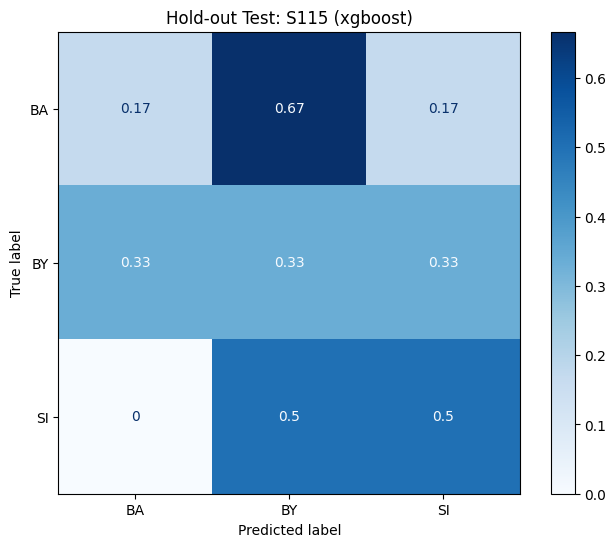

--- Evaluating S113 ---
Train samples: 144 | Test samples: 18
Final Test Accuracy: 0.4444


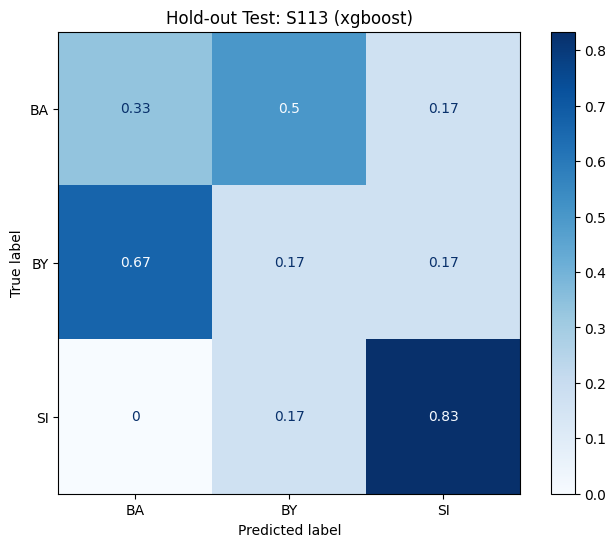

--- Evaluating S114 ---
Train samples: 144 | Test samples: 18
Final Test Accuracy: 0.1667


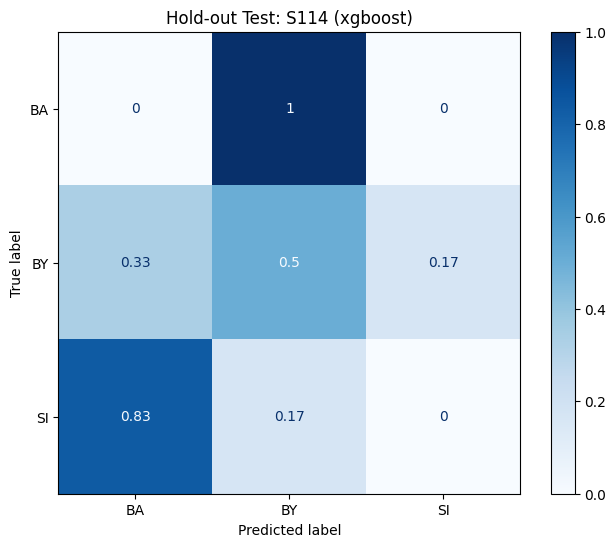

In [ ]:
xgb_acc_dict = model_performance(total_data, test_data,clf_type='xgboost')